# Combining RNA & ATAC multiome of in vitro and vivo

In [1]:
suppressPackageStartupMessages({ # this first line makes sure you don't get all the start up messages
    library(data.table) # used for manipulating data
    library(dplyr) # used for the 'pipes'
    library(ggplot2) # used for plotting data
    library(Seurat)
    library(Signac)
    library(SingleCellExperiment)
    library(dplyr)
    #library(celldex)
    #library(SingleR)
    library(RColorBrewer)
    library(future)
    library(parallel)
})

In [2]:
# # Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

In [3]:
# We can add colours as well if you really want! 
# this is the colour scheme, we usually keep this in a seperate file that we then call in our notebooks
celltype.colors = c(
  "Epiblast" = "#635547",
  "Primitive_Streak" = "#DABE99",
  "Caudal_epiblast" = "#9e6762",
  "PGC" = "#FACB12",
  "Anterior_Primitive_Streak" = "#c19f70",
  "Notochord" = "#0F4A9C",
  "Def._endoderm" = "#F397C0",
  "Gut" = "#EF5A9D",
  "Nascent_mesoderm" = "#C594BF",
  "Mixed_mesoderm" = "#DFCDE4",
  "Intermediate_mesoderm" = "#139992",
  "Caudal_Mesoderm" = "#3F84AA",
  "Paraxial_mesoderm" = "#8DB5CE",
  "Somitic_mesoderm" = "#005579",
  "Pharyngeal_mesoderm" = "#C9EBFB",
  "Cardiomyocytes" = "#B51D8D",
  "Allantois" = "#532C8A",
  "ExE_mesoderm" = "#8870ad",
  "Mesenchyme" = "#cc7818",
  "Haematoendothelial_progenitors" = "#FBBE92",
  "Endothelium" = "#ff891c",
  "Blood_progenitors" = "#c9a997",
  "Blood_progenitors_1" = "#f9decf",
  "Blood_progenitors_2" = "#c9a997",
  "Erythroid" = "#EF4E22",
  "Erythroid1" = "#C72228",
  "Erythroid2" = "#f79083",
  "Erythroid3" = "#EF4E22",
  "NMP" = "#8EC792",
  "Neurectoderm" = "#65A83E",
  "Rostral_neurectoderm" = "#65A83E",
  "Caudal_neurectoderm" = "#354E23",
  "Neural_crest" = "#C3C388",
  "Forebrain_Midbrain_Hindbrain" = "#647a4f",
  "Spinal_cord" = "#CDE088",
  "Surface_ectoderm" = "#f7f79e",
  "Visceral_endoderm" = "#F6BFCB",
  "ExE_endoderm" = "#7F6874",
  "ExE_ectoderm" = "#989898",
  "Parietal_endoderm" = "#1A1A1A"
)

## Set Data Locations

In [8]:
io = list() # here we make an object called 'io', standing for input/output, which is an empty list
# now we are going to assign paths to files to this io list
io$main = "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood" # this is the main directory

#Specify paths to HE multiome files
io$multiome_HE_metadata = file.path(io$main, "results/atac/archR/qc/sample_metadata_update.txt.gz") # This specifies to a location within the main folder
#io$multiome_HE_peakmatrix = file.path(io$main, "processed/atac/archR/Matrices/PeakMatrix_atlas_summarized_experiment.rds")

#Specify paths to reference atlas
io$multiome_atlas =  "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome"
#io$multiome_peakmatrix = file.path(io$multiome_atlas, "data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
io$multiome_metadata = file.path(io$multiome_atlas, "results/atac/archR/qc/sample_metadata_after_qc.txt.gz")

#outdir
io$outdir = file.path(io$main, '/results/multiome_atlas_integration/')

### Load data

In [9]:
# metadata
atlas_meta = fread(io$multiome_metadata)[pass_rnaQC == TRUE & pass_atacQC == TRUE & doublet_call==FALSE & !sample %in% c('E8.5_CRISPR_T_KO', 'E8.5_CRISPR_T_WT')]
vitro_meta = fread(io$multiome_HE_metadata)[pass_rnaQC == TRUE & pass_atacQC == TRUE & doublet_call==FALSE] %>% 
    .[,stage:=day] 
colnames = intersect(colnames(vitro_meta), colnames(atlas_meta))
combined_meta = rbind(atlas_meta[,c(colnames), with=FALSE], vitro_meta[,c(colnames), with=FALSE])

# rna.seurat
rna.seurat = readRDS(sprintf('%s/rna/integrated_regress.rds', io$outdir))

# atac.seurat
atac.mtx = readRDS(sprintf('%s/atac/atac_counts.rds', io$outdir))
atac.lsi = readRDS(sprintf('%s/atac/integrated_lsi.rds', io$outdir))@cell.embeddings

# Filter cells shared between all
cells_keep = intersect(colnames(rna.seurat), colnames(atac.mtx))
combined_meta = combined_meta[cell %in% cells_keep]

rna.seurat = rna.seurat[,combined_meta$cell]
atac.mtx = atac.mtx[,combined_meta$cell]
atac.lsi = atac.lsi[combined_meta$cell, ]

In [121]:
# merge RNA & ATAC
multiome.seurat = rna.seurat
multiome.seurat@meta.data = combined_meta %>% as.data.frame(.) %>% tibble::column_to_rownames('cell') # add metadata
#multiome.seurat[['peaks']] = atac.seurat[['peaks']]

# or this
multiome.seurat[['ATAC']] <- CreateChromatinAssay(
  counts = atac.mtx,
  sep = c(":", "-"),
  genome = "mm10",
  fragments = NULL
)

# Add LSI reductions
multiome.seurat[["lsi"]] <- CreateDimReducObject(embeddings = atac.lsi, key = "LSI_", assay = "ATAC")

ERROR: Error in (function (cl, name, valueClass) : ‘cell.embeddings’ is not a slot in class “NULL”


In [128]:
multiome.seurat[["lsi"]] <- CreateDimReducObject(embeddings = atac.lsi, key = "LSI_", assay = "ATAC")

In [129]:
# WNN RNA & ATAC integration
multiome.seurat <- FindMultiModalNeighbors(
  multiome.seurat, reduction.list = list("pca", "lsi"), 
  dims.list = list(1:25, 1:25), modality.weight.name = "RNA.weight"
)

multiome.seurat <- RunUMAP(multiome.seurat, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
multiome.seurat <- FindClusters(multiome.seurat, graph.name = "wsnn", algorithm = 3, resolution = 2, verbose = FALSE)


Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Warning message in FindMultiModalNeighbors(multiome.seurat, reduction.list = list("pca", :
“The number of provided modality.weight.name is not equal to the number of modalities. integrated.weight ATAC.weight are used to store the modality weights”
Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
17:01:30 UMAP embedding parameters a = 0.9922 b = 1.112

17:01:32 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 20

17:01:35 Initializing from normalized Laplacian + noise (using irlba)

17:01:38 Comme

ERROR: Error in is.data.frame(x): object 'bm' not found


17:09:02 UMAP embedding parameters a = 0.7669 b = 1.223

17:09:04 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 20

17:09:06 Initializing from normalized Laplacian + noise (using irlba)

17:09:10 Commencing optimization for 200 epochs, with 2389010 positive edges

17:10:52 Optimization finished



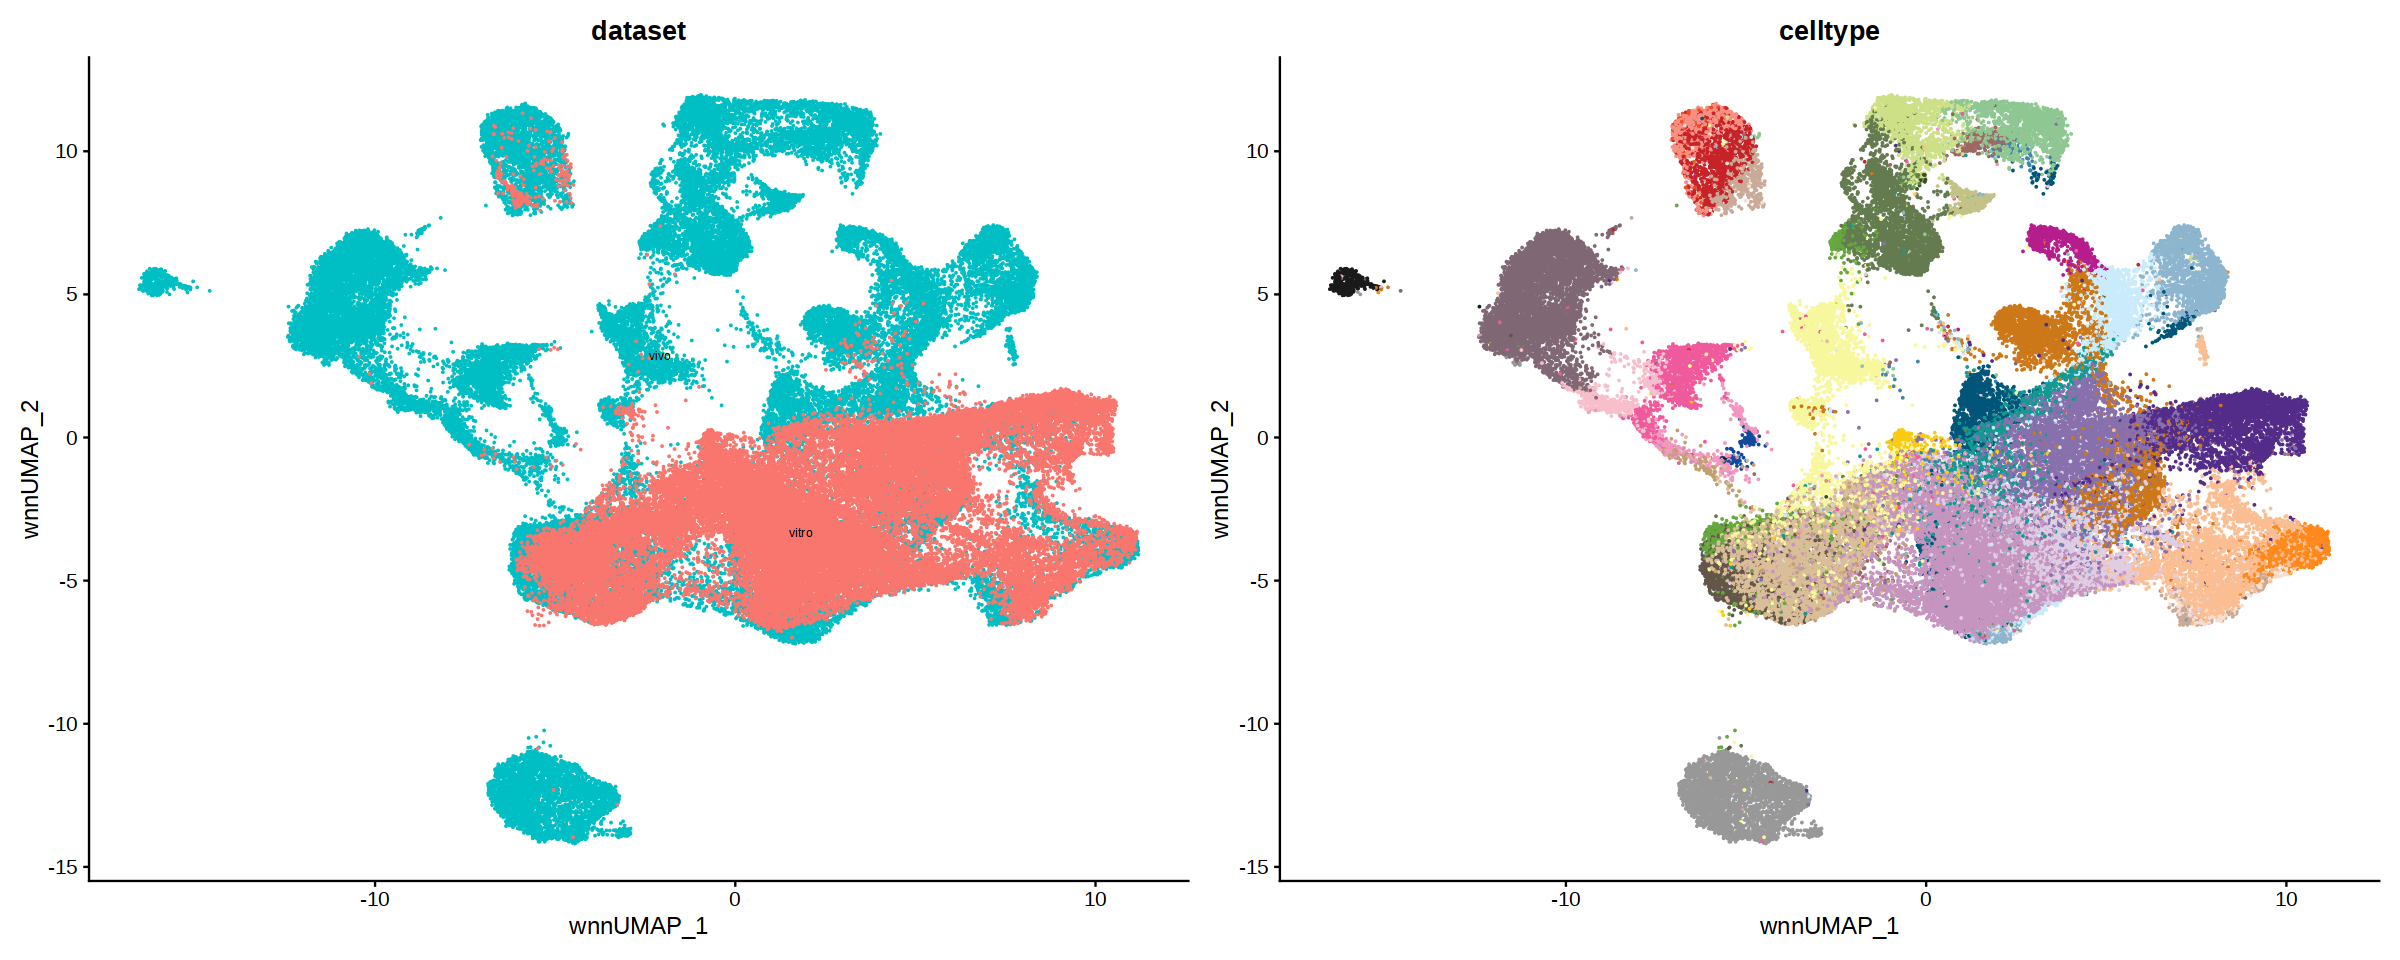

In [139]:
multiome.seurat@meta.data$dataset = ifelse(multiome.seurat@meta.data$genotype == 'WT', 'vivo', 'vitro')
options(repr.plot.width=20, repr.plot.height=8)
multiome.seurat <- RunUMAP(multiome.seurat, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_", min.dist = 0.4)
p1 <- DimPlot(multiome.seurat, reduction = 'wnn.umap', group.by = 'dataset',label = TRUE, repel = TRUE, label.size = 2.5) + NoLegend()
p2 <- DimPlot(multiome.seurat, reduction = 'wnn.umap', group.by = "celltype") + scale_color_manual(values=celltype.colors) + theme(legend.position='false')
p1 + p2

In [144]:
# WNN RNA & ATAC integration
multiome.seurat <- FindMultiModalNeighbors(
  multiome.seurat, reduction.list = list("pca", "lsi"), 
  dims.list = list(1:35, 1:35), modality.weight.name = "RNA.weight"
)

multiome.seurat <- RunUMAP(multiome.seurat, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
#multiome.seurat <- FindClusters(multiome.seurat, graph.name = "wsnn", algorithm = 3, resolution = 2, verbose = FALSE)


Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Warning message in FindMultiModalNeighbors(multiome.seurat, reduction.list = list("pca", :
“The number of provided modality.weight.name is not equal to the number of modalities. integrated.weight ATAC.weight are used to store the modality weights”
Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

17:15:19 UMAP embedding parameters a = 0.9922 b = 1.112

17:15:21 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 20

17:15:24 Initializing from normalized Laplacian + noise (using irlba)

17:15:28 Commencing optimization for 200 epochs, with 2380616 positive edges

17:17:12 Optimization finished



17:17:12 UMAP embedding parameters a = 0.7669 b = 1.223

17:17:13 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 20

17:17:15 Initializing from normalized Laplacian + noise (using irlba)

17:17:19 Commencing optimization for 200 epochs, with 2380616 positive edges

17:19:01 Optimization finished



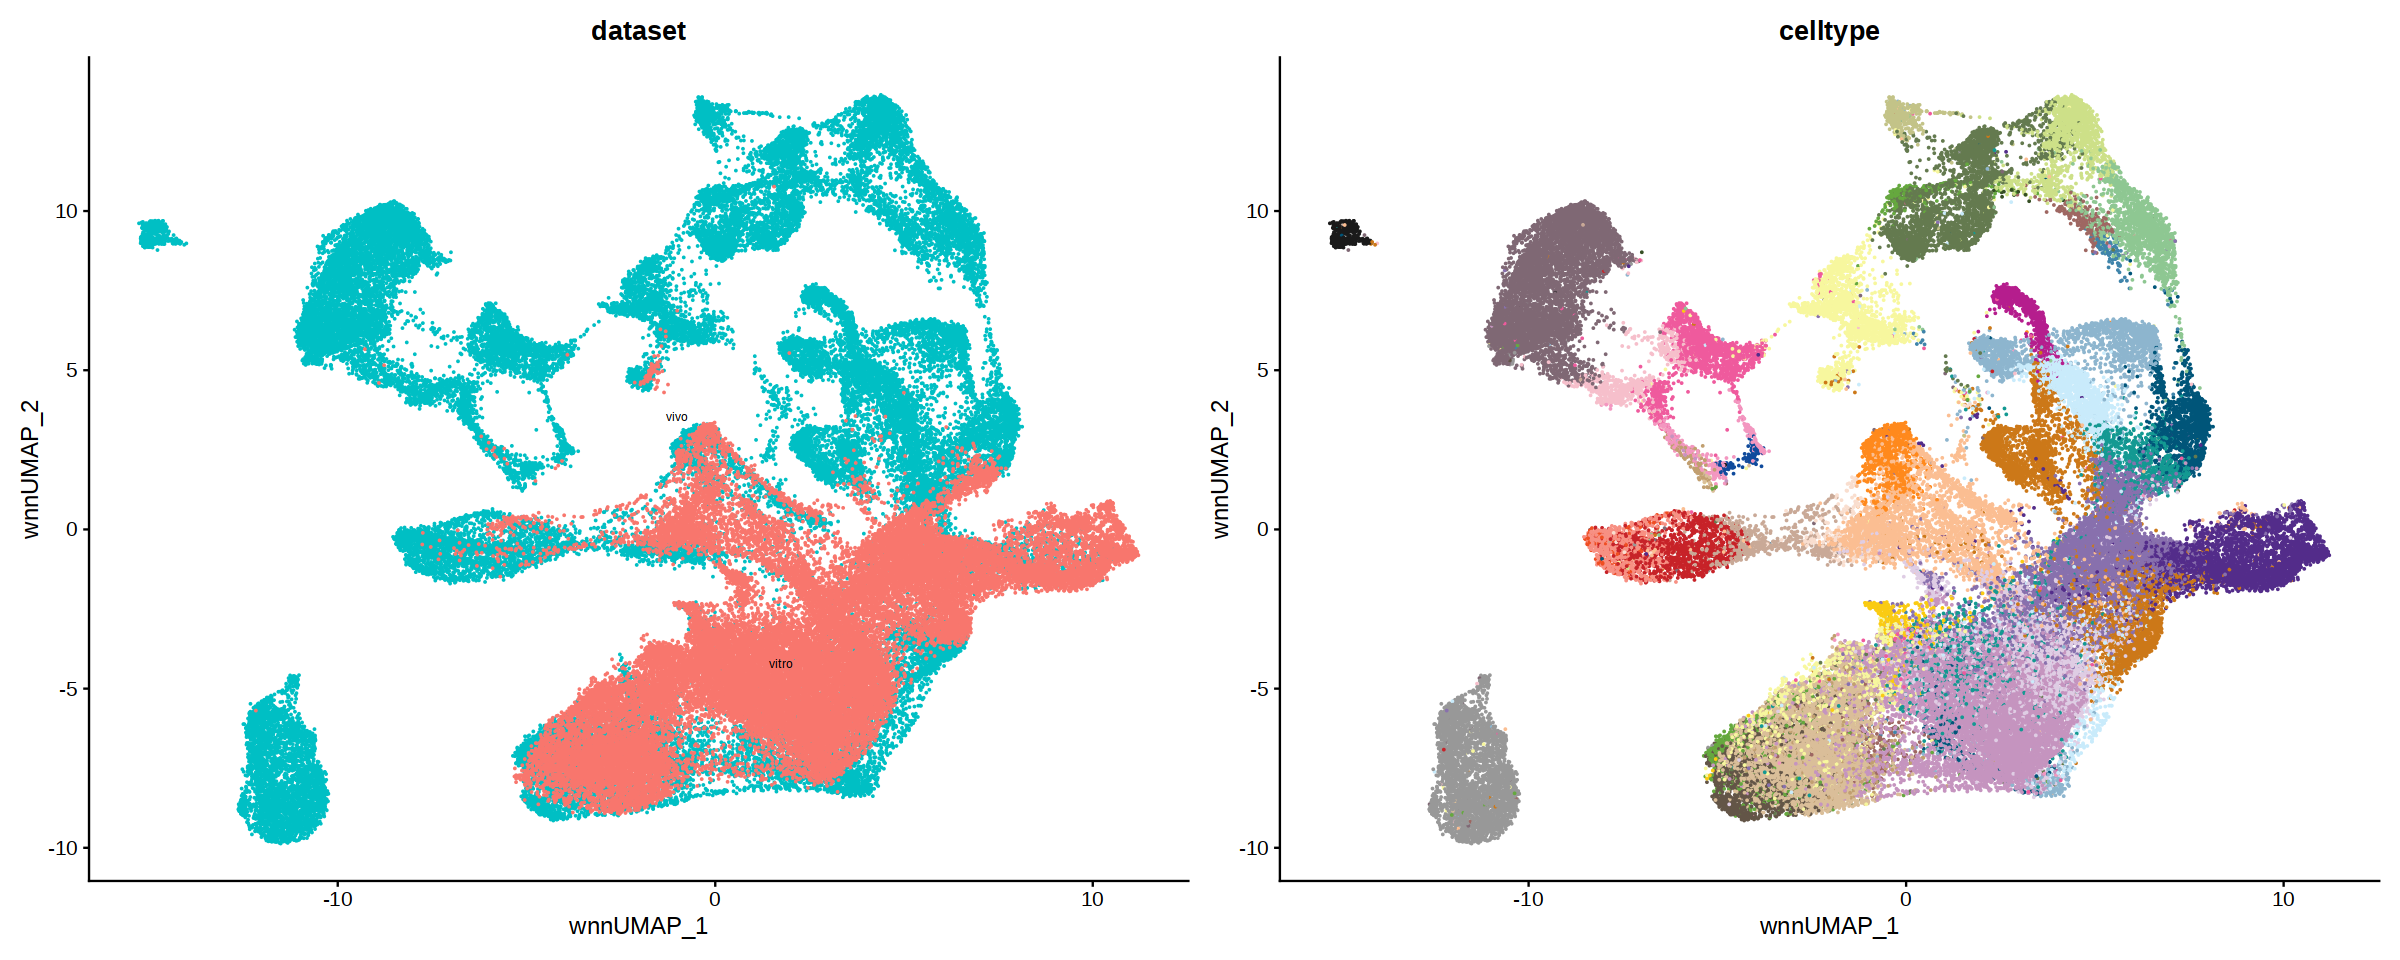

In [145]:
multiome.seurat@meta.data$dataset = ifelse(multiome.seurat@meta.data$genotype == 'WT', 'vivo', 'vitro')
options(repr.plot.width=20, repr.plot.height=8)
multiome.seurat <- RunUMAP(multiome.seurat, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_", min.dist = 0.4)
p1 <- DimPlot(multiome.seurat, reduction = 'wnn.umap', group.by = 'dataset',label = TRUE, repel = TRUE, label.size = 2.5) + NoLegend()
p2 <- DimPlot(multiome.seurat, reduction = 'wnn.umap', group.by = "celltype") + scale_color_manual(values=celltype.colors) + theme(legend.position='false')
p1 + p2

In [ ]:
 VlnPlot(multiome.seurat, features = "ATAC.weight", group.by = 'celltype', sort = TRUE, pt.size = 0) +
  NoLegend()+ scale_fill_manual(values=celltype.colors)

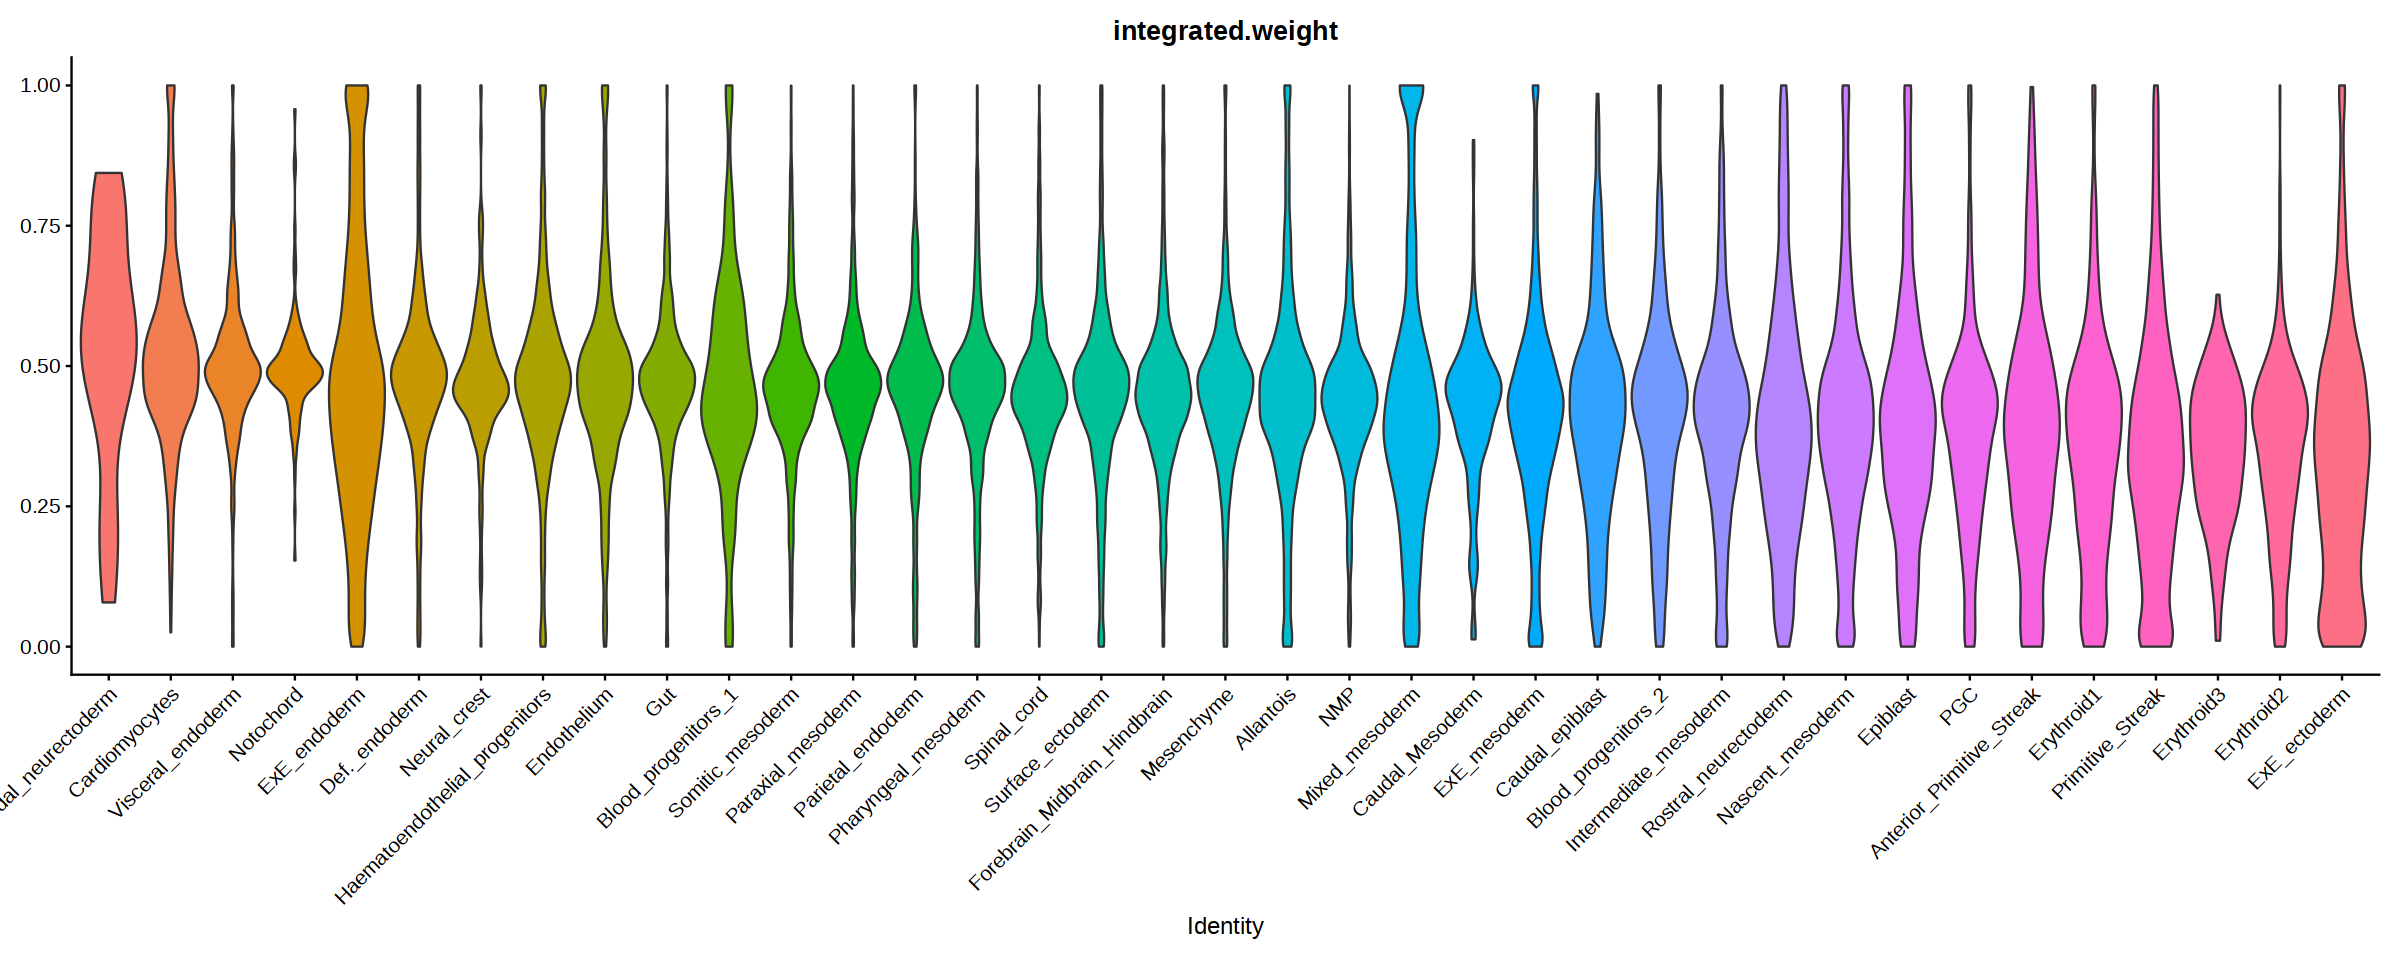

In [153]:
 VlnPlot(multiome.seurat, features = "integrated.weight", group.by = 'celltype', sort = TRUE, pt.size = 0) +
  NoLegend()+ scale_fill_manual(values=celltype.colors)

# MOFA

In [30]:
io$outdir_mofa = file.path(io$outdir, 'mofa/')
dir.create(io$outdir_mofa, recursive=TRUE, showWarnings =FALSE)

In [31]:
library(MOFA2)

In [32]:
PCA = scale(rna.seurat@reductions$pca@cell.embeddings)
LSI = scale(atac.lsi)

In [33]:
summary(rownames(LSI) == rownames(PCA))

   Mode    TRUE 
logical   78391 

In [34]:
MOFAobject <- create_mofa(list(t(PCA[,1:30]), t(LSI[,1:30])))

Creating MOFA object from a list of matrices (features as rows, sample as columns)...


View names are not specified in the data, using default: view_1, view_2




In [35]:
data_opts <- get_default_data_options(MOFAobject)
model_opts <- get_default_model_options(MOFAobject)
train_opts <- get_default_training_options(MOFAobject)

In [36]:
MOFAobject <- prepare_mofa(
  object = MOFAobject,
  data_options = data_opts,
  model_options = model_opts,
  training_options = train_opts
)

Checking data options...

Checking training options...

Checking model options...



In [37]:
outfile = file.path(io$outdir_mofa,"model_v3.hdf5")
MOFAobject.trained <- run_mofa(MOFAobject, outfile)

Connecting to the mofapy2 python package using reticulate (use_basilisk = FALSE)... 
    Please make sure to manually specify the right python binary when loading R with reticulate::use_python(..., force=TRUE) or the right conda environment with reticulate::use_condaenv(..., force=TRUE)
    If you prefer to let us automatically install a conda environment with 'mofapy2' installed using the 'basilisk' package, please use the argument 'use_basilisk = TRUE'




In [ ]:
plot_variance_explained(MOFAobject.trained, x="group", y="factor", plot_total = T)

In [38]:
factors <- get_factors(MOFAobject.trained, factors = "all")

In [40]:
umap = uwot::umap(factors$group1, n_neighbors = 25, min_dist = 0.3)

In [47]:
# metadata
atlas_meta = fread(io$multiome_metadata)[pass_rnaQC == TRUE & pass_atacQC == TRUE & doublet_call==FALSE & !sample %in% c('E8.5_CRISPR_T_KO', 'E8.5_CRISPR_T_WT')] %>%
    .[,`:=`(day = NA, 
            genotype = NA,
           dataset = 'Atlas')]
vitro_meta = fread(io$multiome_HE_metadata)[pass_rnaQC == TRUE & pass_atacQC == TRUE & doublet_call==FALSE] %>% 
    .[,stage:=day] %>%
    .[,`:=`(celltype = NA, 
            stage = NA,
           dataset = 'Eomes_HE')]
colnames = intersect(colnames(vitro_meta), colnames(atlas_meta))
combined_meta = rbind(atlas_meta[,c(colnames), with=FALSE], vitro_meta[,c(colnames), with=FALSE])

In [48]:
umap.dt = as.data.table(umap, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    merge(., combined_meta, by='cell')

In [64]:
plot = function(data = umap.dt, color){
    ggplot(data, aes_string('UMAP1', 'UMAP2', col=color)) + 
        geom_point(size=0.2) + 
        guides(colour = guide_legend(override.aes = list(size=4))) + 
        ggtitle(color) +
        theme_void() +
        theme(text=element_text(size=15), 
             plot.title=element_text(size=20), 
             legend.position='bottom')
}

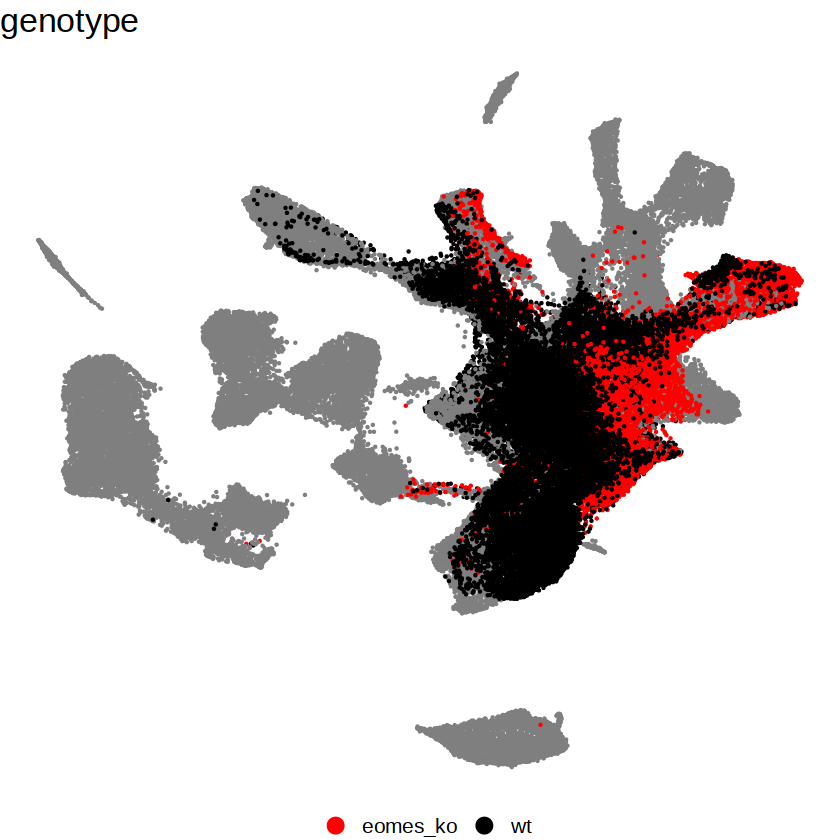

In [65]:
plot(color='genotype') +
        scale_color_manual(values=c('wt' = 'black', 'eomes_ko' = 'red'), name='')

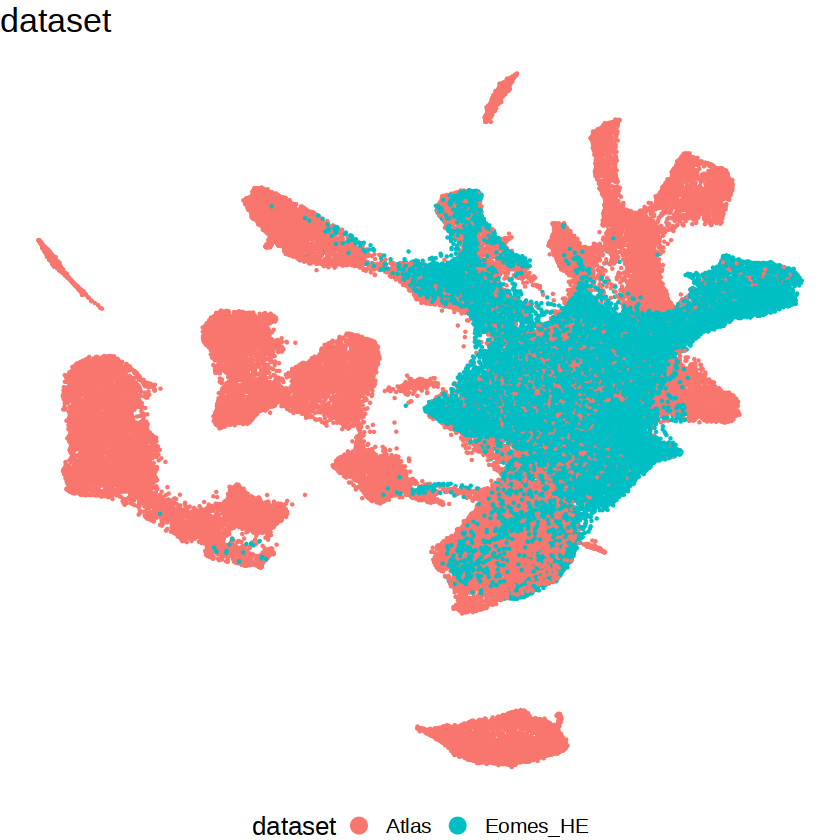

In [61]:
plot(color='dataset')

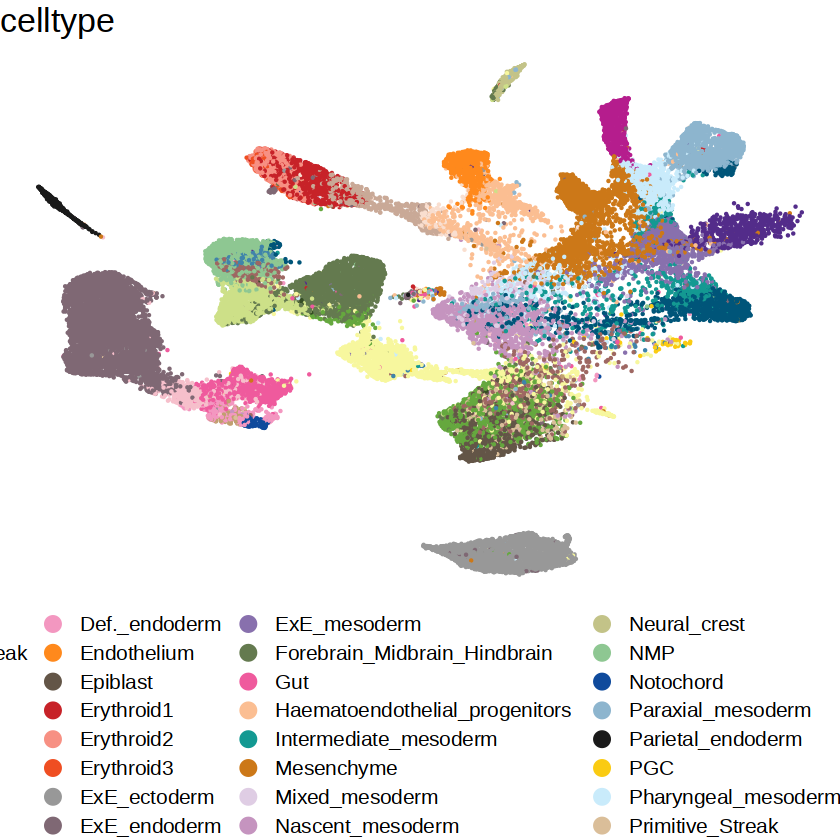

In [67]:
plot(data = umap.dt[dataset=='Atlas'], color='celltype') +
        scale_color_manual(values=celltype.colors, name='')

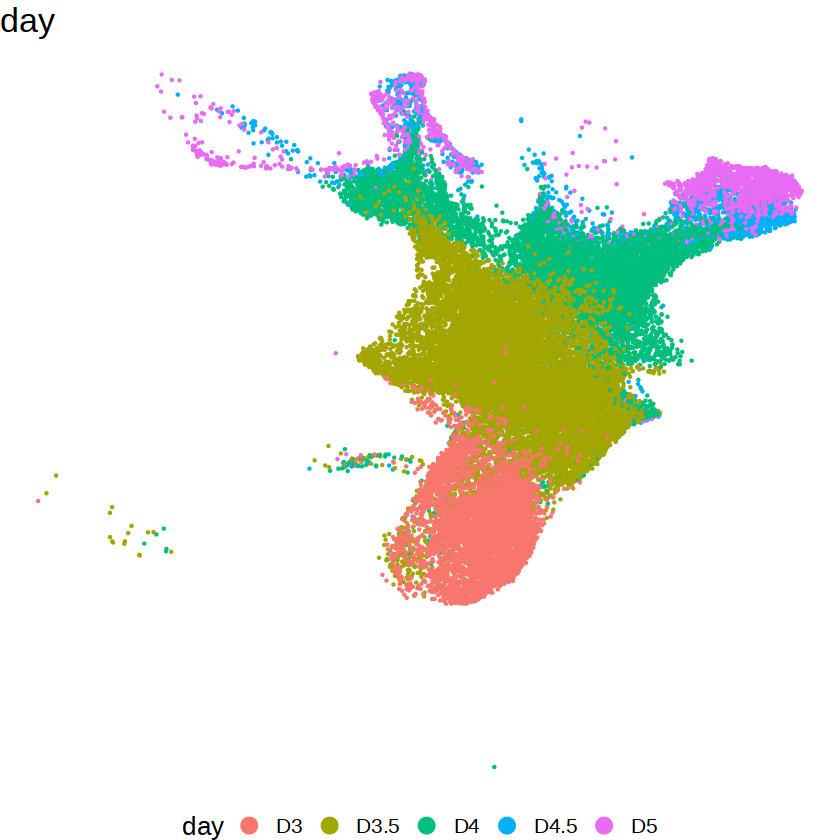

In [70]:
plot(data = umap.dt[dataset=='Eomes_HE'], color='day')